# Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from scipy.stats import skew, ttest_ind
from functions import plot

# Variables

In [3]:
log_trans = True

# Format data

In [4]:
df_org = pd.read_excel("../data/unformated/Daten_Label_24hWt.xlsx", sheet_name="formatted")
rows_unl = [i for i in range(len(df_org)) if i % 2 == 0]
rows_l = [i for i in range(len(df_org)) if i % 2 != 0]
df = df_org.drop(rows_l, axis=0)
df_l = df_org.drop(rows_unl, axis=0)

In [5]:
# add labeled values as new columns
cols = df_org.columns[1:]
for col in cols:
    df[f"{col}_l"] = df_l[col].values

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,1.440343,1.202063,0.000000,0.042314,0.000000,0.685638,1.190872,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000000,0.000000,0.000000,0.000000,0.020399,0.023651,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Preprocessing
## Relative values

In [6]:
cols = df.columns[1:]

for col in cols:
    exp = col.split("_")[0]
    exp_cols = [col for col in cols if "rel" not in col and exp in col]
    sum_exp = df[exp_cols].to_numpy().sum()
    abs_values = df[col].values
    rel_values = [val/sum_exp for val in abs_values]

    df[f"{col}_rel"] = rel_values

    # print("Experiment:", exp)
    # print("Experiment columns:", exp_cols)
    # print("Sum experiment:", sum_exp)
    # print("Column:", col)
    # print("Absolute values:", abs_values)
    # print("Relative values:", rel_values)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l_rel,exp2_37deg_4_l_rel,exp4_22deg_1_l_rel,exp4_22deg_2_l_rel,exp4_22deg_3_l_rel,exp4_22deg_4_l_rel,exp4_37deg_1_l_rel,exp4_37deg_2_l_rel,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.001162,0.001266,0.000246,0.000238,0.000142,0.000174,0.001145,0.001812,0.001705,0.001174
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.004126,0.003969,0.000349,0.000387,0.000241,0.000287,0.003608,0.003785,0.002986,0.002778
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000280,0.000322,0.000536,0.000487,0.000305,0.000391,0.000858,0.001080,0.001260,0.000773
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.000499,0.000463,0.000522,0.000505,0.000348,0.000335,0.001069,0.001046,0.000925,0.000838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,0.000164,0.000137,0.000000,0.000005,0.000000,0.000078,0.000136,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.000003,0.000000,0.000000,0.000000,0.000000,0.000002,0.000003,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [7]:
df.filter(regex="exp2").filter(regex="rel").to_numpy().sum()

np.float64(0.9999999999999999)

In [8]:
df.filter(regex="exp4").filter(regex="rel").to_numpy().sum()

np.float64(1.0)

## log Transformation

In [9]:
if log_trans == True:
    rel_cols = [c for c in df.columns if "rel" in c]
    print(rel_cols)

    for col in rel_cols:
        df[col] = df[col].replace(0, 0.00001) # replace zero values, because log(0) not possible
        df[col] = np.log(df[col].values)

df

['exp2_22deg_1_rel', 'exp2_22deg_2_rel', 'exp2_22deg_3_rel', 'exp2_22deg_4_rel', 'exp2_37deg_1_rel', 'exp2_37deg_2_rel', 'exp2_37deg_3_rel', 'exp2_37deg_4_rel', 'exp4_22deg_1_rel', 'exp4_22deg_2_rel', 'exp4_22deg_3_rel', 'exp4_22deg_4_rel', 'exp4_37deg_1_rel', 'exp4_37deg_2_rel', 'exp4_37deg_3_rel', 'exp4_37deg_4_rel', 'exp2_22deg_1_l_rel', 'exp2_22deg_2_l_rel', 'exp2_22deg_3_l_rel', 'exp2_22deg_4_l_rel', 'exp2_37deg_1_l_rel', 'exp2_37deg_2_l_rel', 'exp2_37deg_3_l_rel', 'exp2_37deg_4_l_rel', 'exp4_22deg_1_l_rel', 'exp4_22deg_2_l_rel', 'exp4_22deg_3_l_rel', 'exp4_22deg_4_l_rel', 'exp4_37deg_1_l_rel', 'exp4_37deg_2_l_rel', 'exp4_37deg_3_l_rel', 'exp4_37deg_4_l_rel']


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l_rel,exp2_37deg_4_l_rel,exp4_22deg_1_l_rel,exp4_22deg_2_l_rel,exp4_22deg_3_l_rel,exp4_22deg_4_l_rel,exp4_37deg_1_l_rel,exp4_37deg_2_l_rel,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-6.757245,-6.671850,-8.311585,-8.341618,-8.862206,-8.656980,-6.772727,-6.313422,-6.374105,-6.747303
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-5.490358,-5.529308,-7.961817,-7.856085,-8.331153,-8.157087,-5.624468,-5.576714,-5.813774,-5.885959
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-8.181304,-8.040336,-7.531149,-7.626976,-8.094885,-7.845562,-7.061437,-6.831190,-6.676826,-7.165648
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-7.603799,-7.677163,-7.558736,-7.591533,-7.963641,-8.002678,-6.841060,-6.862577,-6.986078,-7.084766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-11.512925,-11.512925,-8.713410,-8.894252,-11.512925,-12.240917,-11.512925,-9.455696,-8.903605,-11.512925
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-12.747951,-11.512925,-11.512925,-11.512925,-11.512925,-12.970567,-12.822656,-11.512925,-11.512925,-11.512925
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925


## Statistics

### Mean and Std

In [ ]:
groups = ["22deg", "37deg", "22deg_l", "37deg_l"]
filters = [r".*_22deg_\d+_rel", r".*_37deg_\d+_rel", r".*_22deg_\d+_l_rel", r".*_37deg_\d+_l_rel"]

for g, f in zip(groups, filters):
    df[f"mean_{g}"] = df.filter(regex=f).mean(axis=1)
    df[f"sd_{g}"] = df.filter(regex=f).std(axis=1)

### T-test

In [11]:
## ttest between 22deg and 37deg
for control, heat, label in [[r".*_22deg_\d+_rel", r".*_37deg_\d+_rel", ""], [r".*_22deg_\d+_l_rel", r".*_37deg_\d+_l_rel", "_l"]]:
    df[f"t_stat{label}"], df[f"p_val{label}"] = ttest_ind(df.filter(regex=control), df.filter(regex=heat), axis=1)

c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
c:\Users\janni\miniforge3\envs\sphingo\Lib\site-packages\scipy\stats\_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


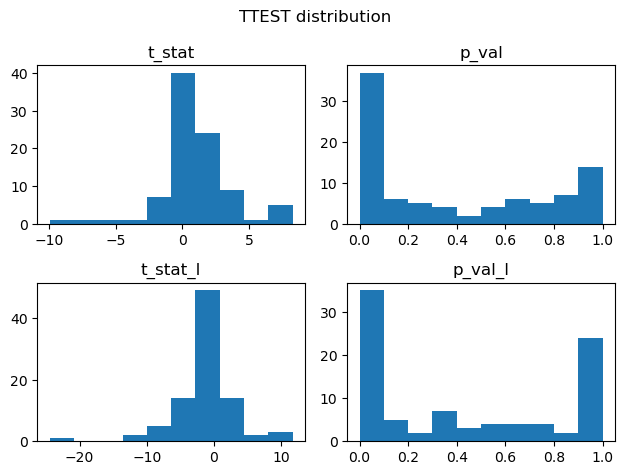

In [12]:
plot(2, 2, "TTEST distribution", df, [["t_stat", "p_val"], ["t_stat_l", "p_val_l"]])

### Fold change

In [11]:
## fold change between 22deg and 37deg
df["fc"] = df["mean_37deg"] - df["mean_22deg"] # -> FC = 1 means under heat stress compound is twice as high 
df["fc_l"] = df["mean_37deg_l"] - df["mean_22deg_l"]
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,mean_22deg_l,sd_22deg_l,mean_37deg_l,sd_37deg_l,t_stat,p_val,t_stat_l,p_val_l,fc,fc_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-8.045963,5.622345e-01,-6.642686,1.896605e-01,-1.855883,0.084642,-6.689113,1.028545e-05,0.149932,1.403277
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-11.512925,1.899005e-15,-11.512925,1.899005e-15,-1.767530,0.098919,0.000000,1.000000e+00,0.791004,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-7.685603,4.586068e-01,-5.691133,1.524203e-01,-5.339864,0.000104,-11.672946,1.332459e-08,0.866858,1.994469
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-7.531778,3.139994e-01,-7.561849,6.912464e-01,8.102284,0.000001,0.112027,9.123923e-01,-1.024581,-0.030071
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-7.638805,2.863447e-01,-7.378244,4.886906e-01,0.999223,0.334645,-1.301156,2.142124e-01,-0.172103,0.260561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-11.512925,1.899005e-15,-11.512925,1.899005e-15,0.000000,1.000000,0.000000,1.000000e+00,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-10.926651,1.334967e+00,-10.929607,1.090128e+00,0.505474,0.621090,0.004851,9.961979e-01,-0.062061,-0.002956
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-12.028495,1.007872e+00,-12.005890,6.817692e-01,0.084160,0.934121,-0.052543,9.588385e-01,-0.029158,0.022604
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-11.512925,1.899005e-15,-11.512925,1.899005e-15,0.000000,1.000000,0.000000,1.000000e+00,0.000000,0.000000


## Skewness

In [12]:
df["skew_22deg_abs"] = [skew(df.filter(regex=r".*_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_37deg_abs"] = [skew(df.filter(regex=r".*_37deg_\d+$").values[i]) for i in range(len(df))]
df["skew_22deg_rel"] = [skew(df.filter(regex=r".*_22deg_\d+_rel$").values[i]) for i in range(len(df))]
df["skew_37deg_rel"] = [skew(df.filter(regex=r".*_37deg_\d+_rel$").values[i]) for i in range(len(df))]
df

C:\Users\janni\AppData\Local\Temp\ipykernel_20816\2819833365.py:3: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_22deg_rel"] = [skew(df.filter(regex=r".*_22deg_\d+_rel$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_20816\2819833365.py:4: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_37deg_rel"] = [skew(df.filter(regex=r".*_37deg_\d+_rel$").values[i]) for i in range(len(df))]


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,t_stat,p_val,t_stat_l,p_val_l,fc,fc_l,skew_22deg_abs,skew_37deg_abs,skew_22deg_rel,skew_37deg_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-1.855883,0.084642,-6.689113,1.028545e-05,0.149932,1.403277,0.054856,0.080237,-0.243100,0.135323
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-1.767530,0.098919,0.000000,1.000000e+00,0.791004,0.000000,1.661805,2.241589,0.904803,1.801300
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-5.339864,0.000104,-11.672946,1.332459e-08,0.866858,1.994469,0.068238,0.142589,-0.185721,-0.155606
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,8.102284,0.000001,0.112027,9.123923e-01,-1.024581,-0.030071,0.144948,0.086108,0.123253,0.161689
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.999223,0.334645,-1.301156,2.142124e-01,-0.172103,0.260561,0.117633,0.120059,-0.267950,0.224140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.505474,0.621090,0.004851,9.961979e-01,-0.062061,-0.002956,0.026585,0.087619,-0.022295,0.321852
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.084160,0.934121,-0.052543,9.588385e-01,-0.029158,0.022604,0.059257,0.264747,-0.027168,0.118003
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN


test


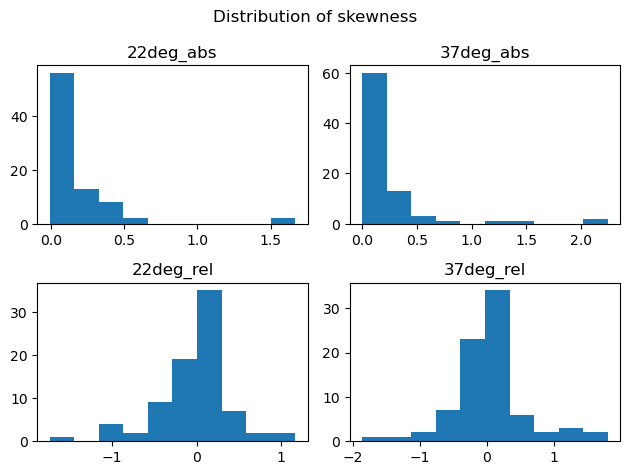

In [14]:
plot(2, 2, "Distribution of skewness", df, [["skew_22deg_abs", "skew_37deg_abs"], ["skew_22deg_rel", "skew_37deg_rel"]])

## Degree of labeling

In [10]:
df["sum_22deg"] = df[["mean_22deg", "mean_22deg_l"]].sum(axis=1)
df["sum_37deg"] = df[["mean_37deg", "mean_37deg_l"]].sum(axis=1)
df["dol_22deg"] = df["mean_22deg_l"] /  df["sum_22deg"]
df["dol_37deg"] = df["mean_37deg_l"] /  df["sum_37deg"]
df.to_csv("../data/formated/wt_24h.csv", index=False)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel,mean_22deg,mean_37deg,mean_22deg_l,mean_37deg_l,sum_22deg,sum_37deg,dol_22deg,dol_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-6.374105,-6.747303,-7.709454,-7.559522,-8.045963,-6.642686,-15.755417,-14.202208,0.510679,0.467722
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-11.512925,-11.512925,-11.081265,-10.290261,-11.512925,-11.512925,-22.594191,-21.803187,0.509552,0.528039
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-5.813774,-5.885959,-7.131562,-6.264705,-7.685603,-5.691133,-14.817165,-11.955838,0.518696,0.476013
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-6.676826,-7.165648,-6.657951,-7.682532,-7.531778,-7.561849,-14.189729,-15.244381,0.530791,0.496042
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-6.986078,-7.084766,-7.138445,-7.310548,-7.638805,-7.378244,-14.777250,-14.688792,0.516930,0.502304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-23.025851,-23.025851,0.500000,0.500000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-8.903605,-11.512925,-4.961468,-5.023530,-10.926651,-10.929607,-15.888119,-15.953136,0.687725,0.685107
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-11.512925,-11.512925,-8.603810,-8.632968,-12.028495,-12.005890,-20.632304,-20.638858,0.582993,0.581713
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-11.512925,-23.025851,-23.025851,0.500000,0.500000


KeyError: 'dol_22deg'

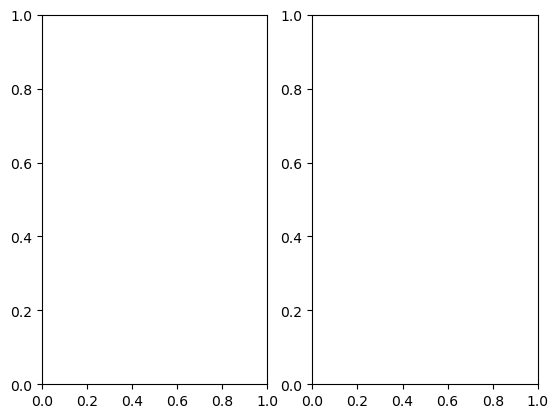

In [35]:
fig, axs = plt.subplots(1, 2)

for i, title in zip([0, 1], ["dol_22deg", "dol_37deg"]):
    axs[i].hist(df[title].values, bins=50)
    axs[i].set_title(f"{title.split("_")[1]}")

plt.suptitle("Distribution of labeling degree")

# To Do
- label degree
- volcano plot
- PCA

# Notes